<h1> Data Loading</h1>

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from datetime import datetime
import statsmodels.api as sm
import numpy as np
from sklearn.preprocessing import StandardScaler

atlas_method = pd.read_csv('data/gni_per_cap_atlas_method_con2021.csv', header=0)
life_expectancy = pd.read_csv('data/life_expectancy.csv', header=0)
population = pd.read_csv('data/population.csv', header=0)


In [18]:
#extra dataframe
co2_emissions=pd.read_csv('data/co2_pcap_cons.csv', header=0)

In [19]:
atlas_method

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,Afghanistan,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,...,751,767,783,800,817,834,852,870,888,907
1,Angola,517.0,519.0,522.0,524.0,525.0,528.0,531.0,533.0,536.0,...,2770,2830,2890,2950,3010,3080,3140,3210,3280,3340
2,Albania,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,...,9610,9820,10k,10.2k,10.5k,10.7k,10.9k,11.1k,11.4k,11.6k
3,United Arab Emirates,738.0,740.0,743.0,746.0,749.0,751.0,754.0,757.0,760.0,...,47.9k,48.9k,50k,51k,52.1k,53.2k,54.3k,55.5k,56.7k,57.9k
4,Argentina,794.0,797.0,799.0,802.0,805.0,808.0,810.0,813.0,816.0,...,12.8k,13.1k,13.4k,13.6k,13.9k,14.2k,14.5k,14.8k,15.2k,15.5k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,Samoa,373.0,373.0,373.0,373.0,373.0,373.0,373.0,374.0,374.0,...,5330,5440,5560,5670,5790,5920,6040,6170,6300,6440
187,Yemen,197.0,198.0,198.0,199.0,199.0,200.0,200.0,201.0,202.0,...,1440,1470,1500,1530,1560,1590,1630,1660,1700,1730
188,South Africa,800.0,791.0,782.0,773.0,765.0,724.0,724.0,786.0,687.0,...,7630,7790,7960,8130,8300,8480,8660,8840,9030,9220
189,Zambia,213.0,214.0,215.0,215.0,215.0,216.0,216.0,217.0,217.0,...,1260,1290,1320,1340,1370,1400,1430,1460,1490,1520


<h1>Data Handling:</h1>

In [20]:
atlas_method= pd.melt(
    atlas_method,
    id_vars=["country"],   # columns to keep fixed
    var_name="Year",       # new column for former column names
    value_name="GNI"       # new column for values
)
atlas_method                               

,country,Year,GNI
0,Afghanistan,1800,207.0
1,Angola,1800,517.0
2,Albania,1800,207.0
3,United Arab Emirates,1800,738.0
4,Argentina,1800,794.0
...,...,...,...
47936,Samoa,2050,6440
47937,Yemen,2050,1730
47938,South Africa,2050,9220
47939,Zambia,2050,1520


In [21]:
life_expectancy  

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,Afghanistan,28.2,28.2,28.2,28.2,28.2,28.2,28.1,28.1,28.1,...,75.5,75.7,75.8,76.0,76.1,76.2,76.4,76.5,76.6,76.8
1,Angola,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,...,78.8,79.0,79.1,79.2,79.3,79.5,79.6,79.7,79.9,80.0
2,Albania,35.4,35.4,35.4,35.4,35.4,35.4,35.4,35.4,35.4,...,87.4,87.5,87.6,87.7,87.8,87.9,88.0,88.2,88.3,88.4
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,United Arab Emirates,30.7,30.7,30.7,30.7,30.7,30.7,30.7,30.7,30.7,...,82.4,82.5,82.6,82.7,82.8,82.9,83.0,83.1,83.2,83.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Samoa,25.4,25.4,25.4,25.4,25.4,25.4,25.4,25.4,25.4,...,79.8,79.9,80.0,80.1,80.3,80.4,80.5,80.6,80.7,80.8
191,Yemen,23.4,23.4,23.4,23.4,23.4,23.4,23.4,23.4,23.4,...,76.9,77.0,77.1,77.3,77.4,77.5,77.6,77.8,77.9,78.0
192,South Africa,33.5,33.5,33.5,33.5,33.5,33.5,33.5,33.5,33.5,...,76.4,76.5,76.7,76.8,77.0,77.1,77.3,77.4,77.5,77.7
193,Zambia,32.6,32.6,32.6,32.6,32.6,32.6,32.6,32.6,32.6,...,75.8,76.0,76.1,76.3,76.4,76.5,76.7,76.8,77.0,77.1


In [22]:
life_expectancy = pd.melt(
    life_expectancy,
    id_vars=["country"],   # columns to keep fixed
    var_name="Year",       # new column for former column names
    value_name="LE"        # new column for values
)
life_expectancy  

,country,Year,LE
0,Afghanistan,1800,28.2
1,Angola,1800,27.0
2,Albania,1800,35.4
3,Andorra,1800,NaN
4,United Arab Emirates,1800,30.7
...,...,...,...
58690,Samoa,2100,80.8
58691,Yemen,2100,78.0
58692,South Africa,2100,77.7
58693,Zambia,2100,77.1


In [23]:
population

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,Afghanistan,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,...,108M,108M,109M,109M,109M,110M,110M,110M,111M,111M
1,Angola,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,...,125M,126M,127M,128M,129M,130M,131M,131M,132M,133M
2,Albania,400k,402k,404k,405k,407k,409k,411k,413k,414k,...,1.35M,1.32M,1.29M,1.26M,1.23M,1.21M,1.18M,1.15M,1.12M,1.1M
3,Andorra,2650,2650,2650,2650,2650,2650,2650,2650,2650,...,62.5k,62.2k,61.9k,61.7k,61.4k,61.2k,60.9k,60.7k,60.5k,60.2k
4,United Arab Emirates,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,...,13.5M,13.5M,13.6M,13.7M,13.8M,13.8M,13.9M,14M,14M,14.1M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,Samoa,47.3k,47.3k,47.3k,47.3k,47.3k,47.3k,47.3k,47.2k,47.2k,...,432k,434k,435k,436k,437k,438k,439k,440k,441k,441k
193,Yemen,2.59M,2.59M,2.59M,2.59M,2.59M,2.59M,2.59M,2.59M,2.59M,...,73.2M,73.3M,73.5M,73.6M,73.7M,73.8M,73.9M,74M,74.1M,74.2M
194,South Africa,1.45M,1.45M,1.46M,1.46M,1.47M,1.47M,1.48M,1.49M,1.49M,...,75.6M,75.5M,75.4M,75.3M,75.2M,75.1M,75M,74.8M,74.7M,74.6M
195,Zambia,747k,758k,770k,782k,794k,806k,818k,831k,843k,...,60.3M,60.7M,61.1M,61.5M,61.9M,62.2M,62.6M,62.9M,63.3M,63.6M


In [24]:
population = pd.melt(
    population,
    id_vars=["country"],      # columns to keep fixed
    var_name="Year",          # new column for former column names
    value_name="population"   # new column for values
)
population  

,country,Year,population
0,Afghanistan,1800,3.28M
1,Angola,1800,1.57M
2,Albania,1800,400k
3,Andorra,1800,2650
4,United Arab Emirates,1800,40.2k
...,...,...,...
59292,Samoa,2100,441k
59293,Yemen,2100,74.2M
59294,South Africa,2100,74.6M
59295,Zambia,2100,63.6M


In [25]:
co2_emissions

,geo,name,1800,1801,1802,1803,1804,1805,1806,1807,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,afg,Afghanistan,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.280,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284
1,ago,Angola,0.009,0.009,0.009,0.009,0.009,0.009,0.010,0.010,...,1.278,1.644,1.220,1.184,1.145,1.122,1.145,1.123,1.201,1.225
2,alb,Albania,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,2.266,2.246,2.041,2.013,2.127,2.078,2.051,2.004,2.124,2.103
3,and,Andorra,0.333,0.335,0.337,0.340,0.342,0.345,0.347,0.350,...,5.902,5.833,5.971,6.073,6.268,6.120,6.058,5.631,5.969,5.909
4,are,UAE,0.063,0.063,0.064,0.064,0.064,0.064,0.065,0.065,...,26.970,26.789,26.975,26.676,23.851,23.464,21.242,19.740,20.707,21.122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,wsm,Samoa,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,1.038,1.087,1.213,1.263,1.291,1.322,1.374,1.310,1.401,1.429
188,yem,Yemen,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,0.994,0.937,0.480,0.377,0.363,0.356,0.365,0.362,0.387,0.395
189,zaf,South Africa,0.003,0.003,0.004,0.004,0.004,0.004,0.004,0.004,...,6.204,6.097,5.756,5.680,5.550,5.420,5.683,5.114,5.077,5.179
190,zmb,Zambia,0.255,0.256,0.257,0.258,0.259,0.260,0.261,0.262,...,0.511,0.560,0.519,0.471,0.474,0.467,0.487,0.388,0.416,0.424


In [26]:
# geo is not helpful in our study so we drop it:
co2_emissions = co2_emissions.drop(columns=['geo'])
co2_emissions

,name,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Afghanistan,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.280,0.253,0.262,0.245,0.247,0.254,0.261,0.261,0.279,0.284
1,Angola,0.009,0.009,0.009,0.009,0.009,0.009,0.010,0.010,0.010,...,1.278,1.644,1.220,1.184,1.145,1.122,1.145,1.123,1.201,1.225
2,Albania,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,2.266,2.246,2.041,2.013,2.127,2.078,2.051,2.004,2.124,2.103
3,Andorra,0.333,0.335,0.337,0.340,0.342,0.345,0.347,0.350,0.352,...,5.902,5.833,5.971,6.073,6.268,6.120,6.058,5.631,5.969,5.909
4,UAE,0.063,0.063,0.064,0.064,0.064,0.064,0.065,0.065,0.065,...,26.970,26.789,26.975,26.676,23.851,23.464,21.242,19.740,20.707,21.122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Samoa,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,1.038,1.087,1.213,1.263,1.291,1.322,1.374,1.310,1.401,1.429
188,Yemen,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,0.994,0.937,0.480,0.377,0.363,0.356,0.365,0.362,0.387,0.395
189,South Africa,0.003,0.003,0.004,0.004,0.004,0.004,0.004,0.004,0.004,...,6.204,6.097,5.756,5.680,5.550,5.420,5.683,5.114,5.077,5.179
190,Zambia,0.255,0.256,0.257,0.258,0.259,0.260,0.261,0.262,0.263,...,0.511,0.560,0.519,0.471,0.474,0.467,0.487,0.388,0.416,0.424


In [27]:
co2_emissions = pd.melt(
    co2_emissions,
    id_vars=["name"],      # columns to keep fixed
    var_name="Year",          # new column for former column names
    value_name="co2_emissions"   # new column for values
)
co2_emissions 

,name,Year,co2_emissions
0,Afghanistan,1800,0.001
1,Angola,1800,0.009
2,Albania,1800,0.001
3,Andorra,1800,0.333
4,UAE,1800,0.063
...,...,...,...
42811,Samoa,2022,1.429
42812,Yemen,2022,0.395
42813,South Africa,2022,5.179
42814,Zambia,2022,0.424


In [28]:
co2_emissions = co2_emissions.rename(columns={'name': 'country'})

In [29]:
co2_emissions

,country,Year,co2_emissions
0,Afghanistan,1800,0.001
1,Angola,1800,0.009
2,Albania,1800,0.001
3,Andorra,1800,0.333
4,UAE,1800,0.063
...,...,...,...
42811,Samoa,2022,1.429
42812,Yemen,2022,0.395
42813,South Africa,2022,5.179
42814,Zambia,2022,0.424


<h1>Merging Data Frames</h1>

In [30]:
world_development_statistis = pd.merge(atlas_method, life_expectancy, on=["country", "Year"], how="inner")
world_development_statistis = pd.merge(world_development_statistis, population, on=["country", "Year"], how="inner")
 
world_development_statistis

,country,Year,GNI,LE,population
0,Afghanistan,1800,207.0,28.2,3.28M
1,Angola,1800,517.0,27.0,1.57M
2,Albania,1800,207.0,35.4,400k
3,United Arab Emirates,1800,738.0,30.7,40.2k
4,Argentina,1800,794.0,33.2,534k
...,...,...,...,...,...
47685,Samoa,2050,6440,74.3,320k
47686,Yemen,2050,1730,72.2,55.3M
47687,South Africa,2050,9220,70.9,73.5M
47688,Zambia,2050,1520,69.8,37.5M


In [31]:
world_development_statistis_with_co2emission = pd.merge(world_development_statistis, co2_emissions, on=["country", "Year"], how="inner")
world_development_statistis_with_co2emission 
world_development_statistis_with_co2emission .dtypes

country              str
Year                 str
GNI               object
LE               float64
population           str
co2_emissions    float64
dtype: object

<h1>Modifying Data Type</h1>

In [32]:
#Clean and prepare the value before converting it to a number

def numbers_editting(x):
    
#revert to None instead of trying to convert it to a number    
    if pd.isna(x):
        return None   

#Convert value to string, remove spaces from beginning and end, convert string to lowercase
    x = str(x).strip().lower()
    
#Avoid typing mistakes for nulls
    if x in ['na', 'n/a', '..','', '-']:
        return None
        
#Remove commas in numbers
    x = x.replace(',','')
    
#Convert k, m & b to numbers
    try:
        if 'k' in x:
            return float(x.replace('k',''))*1000
        elif 'm' in x:
            return float(x.replace('m',''))*1000000
        elif 'b' in x:
            return float(x.replace('b',''))*1000000000
        else:
            return float(x)
    
    except:
        return None

In [33]:
world_development_statistis['GNI'] = world_development_statistis['GNI'].apply(numbers_editting)
world_development_statistis['LE'] = world_development_statistis['LE'].apply(numbers_editting)
world_development_statistis['population'] = world_development_statistis['population'].apply(numbers_editting)
world_development_statistis

,country,Year,GNI,LE,population
0,Afghanistan,1800,207.0,28.2,3280000.0
1,Angola,1800,517.0,27.0,1570000.0
2,Albania,1800,207.0,35.4,400000.0
3,United Arab Emirates,1800,738.0,30.7,40200.0
4,Argentina,1800,794.0,33.2,534000.0
...,...,...,...,...,...
47685,Samoa,2050,6440.0,74.3,320000.0
47686,Yemen,2050,1730.0,72.2,55300000.0
47687,South Africa,2050,9220.0,70.9,73500000.0
47688,Zambia,2050,1520.0,69.8,37500000.0


In [34]:
world_development_statistis['country'] = (world_development_statistis)['country']
world_development_statistis['Year'] = pd.to_numeric(world_development_statistis['Year'], errors='coerce')
world_development_statistis_with_co2emission['Year'] = pd.to_numeric(world_development_statistis_with_co2emission['Year'], errors='coerce')
world_development_statistis['GNI'] = pd.to_numeric(world_development_statistis['GNI'], errors='coerce')
world_development_statistis['population'] = pd.to_numeric(world_development_statistis['population'], errors='coerce')

<h1>Descibing Data</h>

In [35]:
world_development_statistis.dtypes

country           str
Year            int64
GNI           float64
LE            float64
population    float64
dtype: object

In [36]:
world_development_statistis_with_co2emission.dtypes

country              str
Year               int64
GNI               object
LE               float64
population           str
co2_emissions    float64
dtype: object

In [37]:
world_development_statistis

,country,Year,GNI,LE,population
0,Afghanistan,1800,207.0,28.2,3280000.0
1,Angola,1800,517.0,27.0,1570000.0
2,Albania,1800,207.0,35.4,400000.0
3,United Arab Emirates,1800,738.0,30.7,40200.0
4,Argentina,1800,794.0,33.2,534000.0
...,...,...,...,...,...
47685,Samoa,2050,6440.0,74.3,320000.0
47686,Yemen,2050,1730.0,72.2,55300000.0
47687,South Africa,2050,9220.0,70.9,73500000.0
47688,Zambia,2050,1520.0,69.8,37500000.0


In [38]:
world_development_statistis_with_co2emission

,country,Year,GNI,LE,population,co2_emissions
0,Afghanistan,1800,207.0,28.2,3.28M,0.001
1,Angola,1800,517.0,27.0,1.57M,0.009
2,Albania,1800,207.0,35.4,400k,0.001
3,Argentina,1800,794.0,33.2,534k,0.119
4,Armenia,1800,111.0,34.0,413k,NaN
...,...,...,...,...,...,...
41473,Samoa,2022,3730,70.8,222k,1.429
41474,Yemen,2022,856,68.0,33.7M,0.395
41475,South Africa,2022,6130,65.9,59.9M,5.179
41476,Zambia,2022,1110,64.0,20M,0.424


In [39]:
world_development_statistis.sample()

,country,Year,GNI,LE,population
35943,Cameroon,1989,1970.0,58.5,11100000.0


In [40]:
world_development_statistis.shape

(47690, 5)

In [41]:
world_development_statistis.dtypes

country           str
Year            int64
GNI           float64
LE            float64
population    float64
dtype: object

In [42]:
#world_development_statistis['LE'] =world_development_statistis['LE'].fillna( world_development_statistis['LE'].mean())
world_development_statistis.isnull().sum()

country          0
Year             0
GNI              0
LE            1086
population       0
dtype: int64

In [43]:
world_development_statistis_with_co2emission.isnull().sum()

country             0
Year                0
GNI                 0
LE                918
population          0
co2_emissions    1805
dtype: int64

In [44]:
world_development_statistis.describe()

,Year,GNI,LE,population
count,47690.000000,47690.000000,46604.000000,4.769000e+04
mean,1925.000000,5133.662948,47.719158,1.759232e+07
std,72.457643,12708.052807,18.642026,8.371393e+07
min,1800.000000,28.000000,1.010000,1.830000e+03
25%,1862.000000,409.000000,32.000000,3.920000e+05
50%,1925.000000,899.000000,39.100000,2.170000e+06
75%,1988.000000,3170.000000,66.300000,8.360000e+06
max,2050.000000,142000.000000,88.600000,1.670000e+09


<h1>Analysis</h1>

<h1>Gross National Income Per Capita</h1>

In [45]:
#Measures of central tendency
world_development_statistis.groupby('country')['GNI'].describe().sort_values(by = 'mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Switzerland,251.0,37577.649402,37271.393841,3640.0,4575.0,19400.0,68650.0,136000.0
Norway,251.0,28268.087649,39215.513118,1630.0,2400.0,5850.0,43150.0,142000.0
Luxembourg,251.0,27990.956175,38123.202151,1260.0,2090.0,5820.0,44350.0,135000.0
United States,251.0,26846.494024,28594.699251,3120.0,5595.0,12600.0,41650.0,116000.0
Denmark,251.0,24577.848606,29673.392677,2340.0,3505.0,8690.0,39550.0,114000.0
...,...,...,...,...,...,...,...,...
Guinea-Bissau,251.0,306.597610,340.640246,108.0,112.0,117.0,335.5,1490.0
Malawi,251.0,301.434263,232.822865,161.0,162.0,175.0,325.5,1160.0
Somalia,251.0,267.621514,78.169125,195.0,207.0,234.0,326.0,535.0


<h1>Deviding countries into groups</h1>

In [46]:
countries=list(world_development_statistis.country.unique())
countries

['Afghanistan',
 'Angola',
 'Albania',
 'United Arab Emirates',
 'Argentina',
 'Armenia',
 'Antigua and Barbuda',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Burundi',
 'Belgium',
 'Benin',
 'Burkina Faso',
 'Bangladesh',
 'Bulgaria',
 'Bahrain',
 'Bahamas',
 'Bosnia and Herzegovina',
 'Belarus',
 'Belize',
 'Bolivia',
 'Brazil',
 'Barbados',
 'Brunei',
 'Bhutan',
 'Botswana',
 'Central African Republic',
 'Canada',
 'Switzerland',
 'Chile',
 'China',
 "Cote d'Ivoire",
 'Cameroon',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Colombia',
 'Comoros',
 'Cape Verde',
 'Costa Rica',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Germany',
 'Djibouti',
 'Dominica',
 'Denmark',
 'Dominican Republic',
 'Algeria',
 'Ecuador',
 'Egypt',
 'Eritrea',
 'Spain',
 'Estonia',
 'Ethiopia',
 'Finland',
 'Fiji',
 'France',
 'Micronesia, Fed. Sts.',
 'Gabon',
 'United Kingdom',
 'Georgia',
 'Ghana',
 'Guinea',
 'Gambia',
 'Guinea-Bissau',
 'Equatorial Guinea',
 'Greece',
 'Grenada',
 'Guatemala',
 'Guyana',
 'Hong Kon

In [47]:
development_map = {
    # DEVELOPED
    'United States':'Developed','Canada':'Developed','Germany':'Developed','France':'Developed',
    'United Kingdom':'Developed','Italy':'Developed','Spain':'Developed','Netherlands':'Developed',
    'Belgium':'Developed','Switzerland':'Developed','Austria':'Developed','Norway':'Developed',
    'Sweden':'Developed','Denmark':'Developed','Finland':'Developed','Ireland':'Developed',
    'Iceland':'Developed','Luxembourg':'Developed','Japan':'Developed','South Korea':'Developed',
    'Singapore':'Developed','Australia':'Developed','New Zealand':'Developed','Israel':'Developed',
    'Czech Republic':'Developed','Slovak Republic':'Developed','Slovenia':'Developed','Estonia':'Developed',
    'Latvia':'Developed','Lithuania':'Developed','Portugal':'Developed','Greece':'Developed',
    'Cyprus':'Developed','Malta':'Developed',

    # HIGH-INCOME GULF (treated as Developed for simplicity)
    'United Arab Emirates':'Developed','Qatar':'Developed','Kuwait':'Developed','Bahrain':'Developed','Saudi Arabia':'Developed','Oman':'Developed','Brunei':'Developed',

    # DEVELOPING (largest group)
    'China':'Developing','India':'Developing','Brazil':'Developing','Mexico':'Developing',
    'Argentina':'Developing','Chile':'Developing','Colombia':'Developing','Peru':'Developing',
    'Uruguay':'Developing','Paraguay':'Developing','Bolivia':'Developing','Ecuador':'Developing',
    'Turkey':'Developing','Russia':'Developing','Ukraine':'Developing','Kazakhstan':'Developing',
    'Romania':'Developing','Bulgaria':'Developing','Serbia':'Developing','Montenegro':'Developing',
    'Bosnia and Herzegovina':'Developing','North Macedonia':'Developing','Albania':'Developing',
    'Belarus':'Developing','Moldova':'Developing','Armenia':'Developing','Azerbaijan':'Developing',
    'Georgia':'Developing','Thailand':'Developing','Malaysia':'Developing','Indonesia':'Developing',
    'Philippines':'Developing','Vietnam':'Developing','Sri Lanka':'Developing','Pakistan':'Developing',
    'Bangladesh':'Developing','Nepal':'Developing','Iran':'Developing','Iraq':'Developing',
    'Jordan':'Developing','Lebanon':'Developing','Palestine':'Developing',
    'Egypt':'Developing','Morocco':'Developing','Tunisia':'Developing','Algeria':'Developing',
    'South Africa':'Developing','Namibia':'Developing','Botswana':'Developing','Gabon':'Developing',
    'Equatorial Guinea':'Developing','Mauritius':'Developing','Seychelles':'Developing',
    'Fiji':'Developing','Tonga':'Developing','Samoa':'Developing','Vanuatu':'Developing',
    'Maldives':'Developing','Bhutan':'Developing','Mongolia':'Developing',
    'Guyana':'Developing','Suriname':'Developing','Belize':'Developing',
    'Costa Rica':'Developing','Panama':'Developing','Dominican Republic':'Developing',
    'Jamaica':'Developing','Cuba':'Developing','El Salvador':'Developing','Guatemala':'Developing',
    'Honduras':'Developing','Nicaragua':'Developing',

    # LEAST DEVELOPED (UN-based)
    'Afghanistan':'Least Developed','Angola':'Least Developed','Benin':'Least Developed',
    'Burkina Faso':'Least Developed','Burundi':'Least Developed','Central African Republic':'Least Developed',
    'Chad':'Least Developed','Comoros':'Least Developed','Congo, Dem. Rep.':'Least Developed',
    'Djibouti':'Least Developed','Eritrea':'Least Developed','Ethiopia':'Least Developed',
    'Gambia':'Least Developed','Guinea':'Least Developed','Guinea-Bissau':'Least Developed',
    'Haiti':'Least Developed','Kiribati':'Least Developed','Lao':'Least Developed',
    'Lesotho':'Least Developed','Liberia':'Least Developed','Madagascar':'Least Developed',
    'Malawi':'Least Developed','Mali':'Least Developed','Mauritania':'Least Developed',
    'Mozambique':'Least Developed','Myanmar':'Least Developed','Niger':'Least Developed',
    'Rwanda':'Least Developed','Sao Tome and Principe':'Least Developed','Senegal':'Least Developed',
    'Sierra Leone':'Least Developed','Solomon Islands':'Least Developed','Somalia':'Least Developed',
    'South Sudan':'Least Developed','Sudan':'Least Developed','Tanzania':'Least Developed',
    'Timor-Leste':'Least Developed','Togo':'Least Developed','Tuvalu':'Least Developed',
    'Uganda':'Least Developed','Yemen':'Least Developed','Zambia':'Least Developed','Zimbabwe':'Least Developed'
}

In [48]:
world_development_statistis['Country_class']=world_development_statistis['country'].map(development_map)

In [49]:
world_development_statistis_with_co2emission['Country_class']=world_development_statistis_with_co2emission['country'].map(development_map)

In [50]:
world_development_statistis

,country,Year,GNI,LE,population,Country_class
0,Afghanistan,1800,207.0,28.2,3280000.0,Least Developed
1,Angola,1800,517.0,27.0,1570000.0,Least Developed
2,Albania,1800,207.0,35.4,400000.0,Developing
3,United Arab Emirates,1800,738.0,30.7,40200.0,Developed
4,Argentina,1800,794.0,33.2,534000.0,Developing
...,...,...,...,...,...,...
47685,Samoa,2050,6440.0,74.3,320000.0,Developing
47686,Yemen,2050,1730.0,72.2,55300000.0,Least Developed
47687,South Africa,2050,9220.0,70.9,73500000.0,Developing
47688,Zambia,2050,1520.0,69.8,37500000.0,Least Developed


In [51]:
world_development_statistis_with_co2emission

,country,Year,GNI,LE,population,co2_emissions,Country_class
0,Afghanistan,1800,207.0,28.2,3.28M,0.001,Least Developed
1,Angola,1800,517.0,27.0,1.57M,0.009,Least Developed
2,Albania,1800,207.0,35.4,400k,0.001,Developing
3,Argentina,1800,794.0,33.2,534k,0.119,Developing
4,Armenia,1800,111.0,34.0,413k,NaN,Developing
...,...,...,...,...,...,...,...
41473,Samoa,2022,3730,70.8,222k,1.429,Developing
41474,Yemen,2022,856,68.0,33.7M,0.395,Least Developed
41475,South Africa,2022,6130,65.9,59.9M,5.179,Developing
41476,Zambia,2022,1110,64.0,20M,0.424,Least Developed


In [52]:
world_development_statistis.groupby('Country_class')['GNI'].describe()

,count,mean,std,min,25%,50%,75%,max
Country_class,,,,,,,,
Developed,10291.0,15802.862987,22839.554539,329.0,1390.0,4220.0,22400.0,142000.0
Developing,18072.0,2359.549247,3659.766992,28.0,397.0,776.0,2580.0,29900.0
Least Developed,10793.0,665.873436,825.856569,81.0,264.0,404.0,711.0,12300.0


<h1>Analysing countries' Groups</h1>

In [53]:
# to see the number of countries in the data frame and get the ratio for each country class 
unique_countries = world_development_statistis[
    ['country', 'Country_class']
].drop_duplicates()

country_ratio = unique_countries['Country_class'].value_counts()

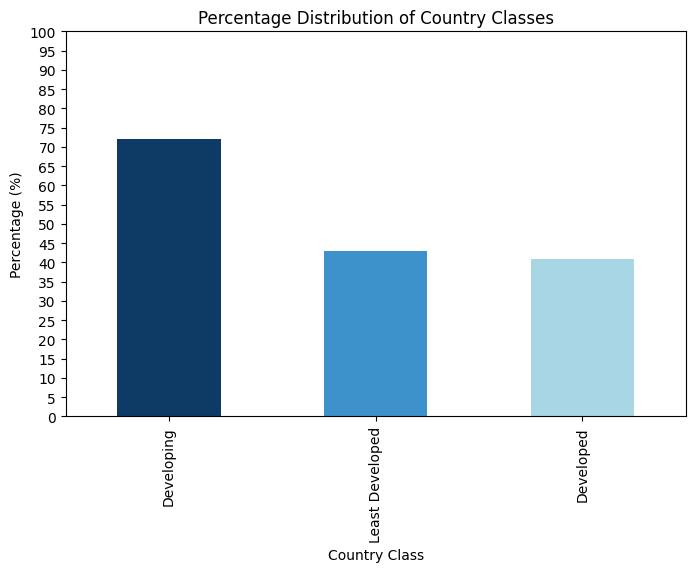

In [54]:
unique_countries = world_development_statistis[
    ['country', 'Country_class']
].drop_duplicates()

country_ratio = unique_countries['Country_class'].value_counts()

colors = ['#0D3B66', '#3E92CC', '#A9D6E5']

country_ratio.plot(
    kind='bar',
    figsize=(8,5),
    color=colors
)

plt.title('Percentage Distribution of Country Classes')
plt.xlabel('Country Class')
plt.ylabel('Percentage (%)')
plt.yticks(range(0, 101, 5))



plt.show()

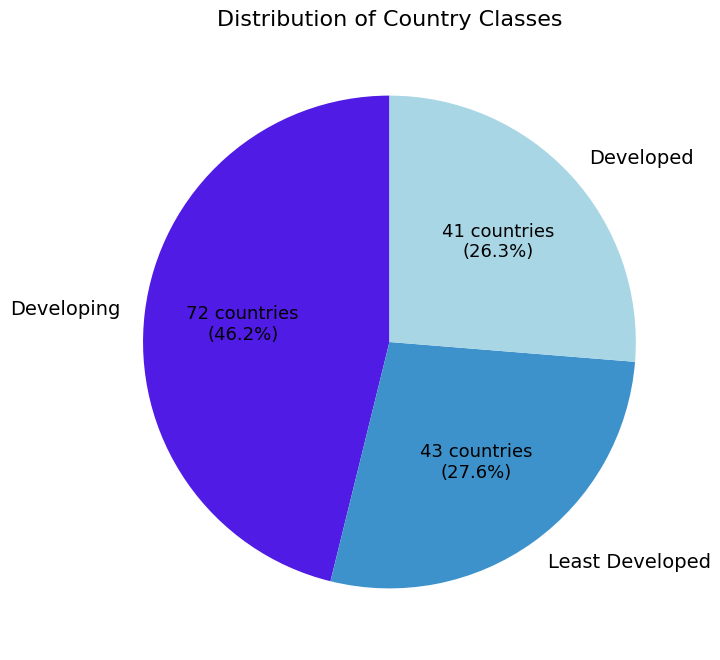

In [55]:
unique_countries = world_development_statistis[
    ['country', 'Country_class']
].drop_duplicates()

country_ratio = unique_countries['Country_class'].value_counts()

colors = ['#501BE5', '#3E92CC', '#A9D6E5']

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val} countries\n({pct:.1f}%)'
    return my_format

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    country_ratio,
    labels=country_ratio.index,
    autopct=autopct_format(country_ratio),
    colors=colors,
    startangle=90
)

# Increase font size outside label font size
for text in texts:
    text.set_fontsize(14)

# Increase font size inside percentage & count font size
for autotext in autotexts:
    autotext.set_fontsize(13)

#Increase title font size
plt.title('Distribution of Country Classes', fontsize=16)

plt.show()

In [56]:
world_development_statistis[world_development_statistis['Country_class']=='Developed'].sample()

,country,Year,GNI,LE,population,Country_class
40980,New Zealand,2015,45100.0,81.7,4590000.0,Developed


In [57]:
world_development_statistis[world_development_statistis['Country_class']=='Developing'].sample()

,country,Year,GNI,LE,population,Country_class
42315,Philippines,2022,3790.0,72.2,116000000.0,Developing


In [58]:
world_development_statistis[world_development_statistis['Country_class']=='Least Developed'].sample()

,country,Year,GNI,LE,population,Country_class
10367,Madagascar,1854,258.0,30.5,2650000.0,Least Developed


<h1>Gross National Income GNI</h1>

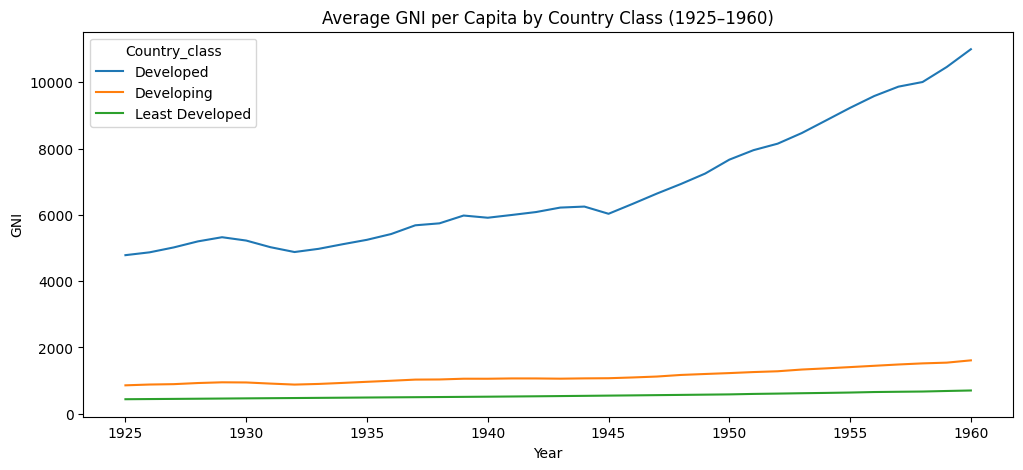

In [59]:
df = world_development_statistis[
    (world_development_statistis['Year'] >= 1925) &
    (world_development_statistis['Year'] <= 1960)
    
]

grouped = df.groupby(['Year', 'Country_class'])['GNI'].mean().unstack()

grouped.plot(figsize=(12,5))

plt.title('Average GNI per Capita by Country Class (1925–1960)')
plt.xlabel('Year')
plt.ylabel('GNI')



plt.show()

In [60]:
grouped.columns

Index(['Developed', 'Developing', 'Least Developed'], dtype='str', name='Country_class')

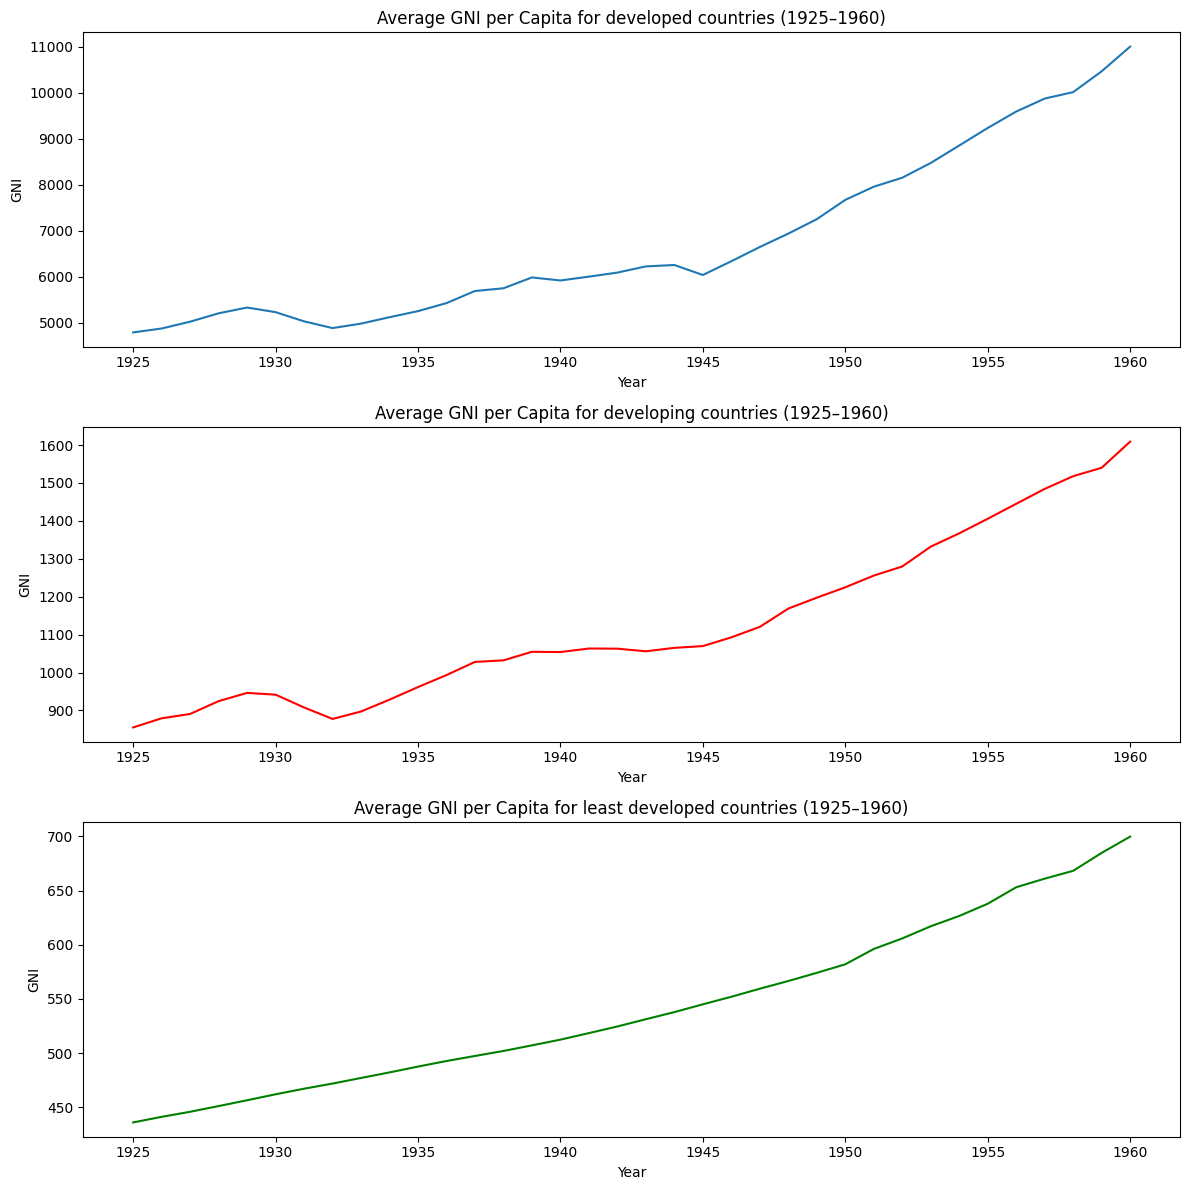

In [61]:
plt.figure(figsize=(12,12))
plt.subplot(3,1,1)
#grouped.plot(figsize=(12,5))
plt.plot(grouped.index, grouped['Developed'])
plt.title('Average GNI per Capita for developed countries (1925–1960)')
plt.xlabel('Year')
plt.ylabel('GNI')


plt.subplot(3,1,2)
#grouped.plot(figsize=(12,5))
plt.plot(grouped.index, grouped['Developing'],color="red")
plt.title('Average GNI per Capita for developing countries (1925–1960)')
plt.xlabel('Year')
plt.ylabel('GNI')


plt.subplot(3,1,3)
#grouped.plot(figsize=(12,5))
plt.plot(grouped.index, grouped['Least Developed'],color="green")
plt.title('Average GNI per Capita for least developed countries (1925–1960)')
plt.xlabel('Year')
plt.ylabel('GNI')


plt.tight_layout()
plt.show()

<h1>Life Expectancy</h1>

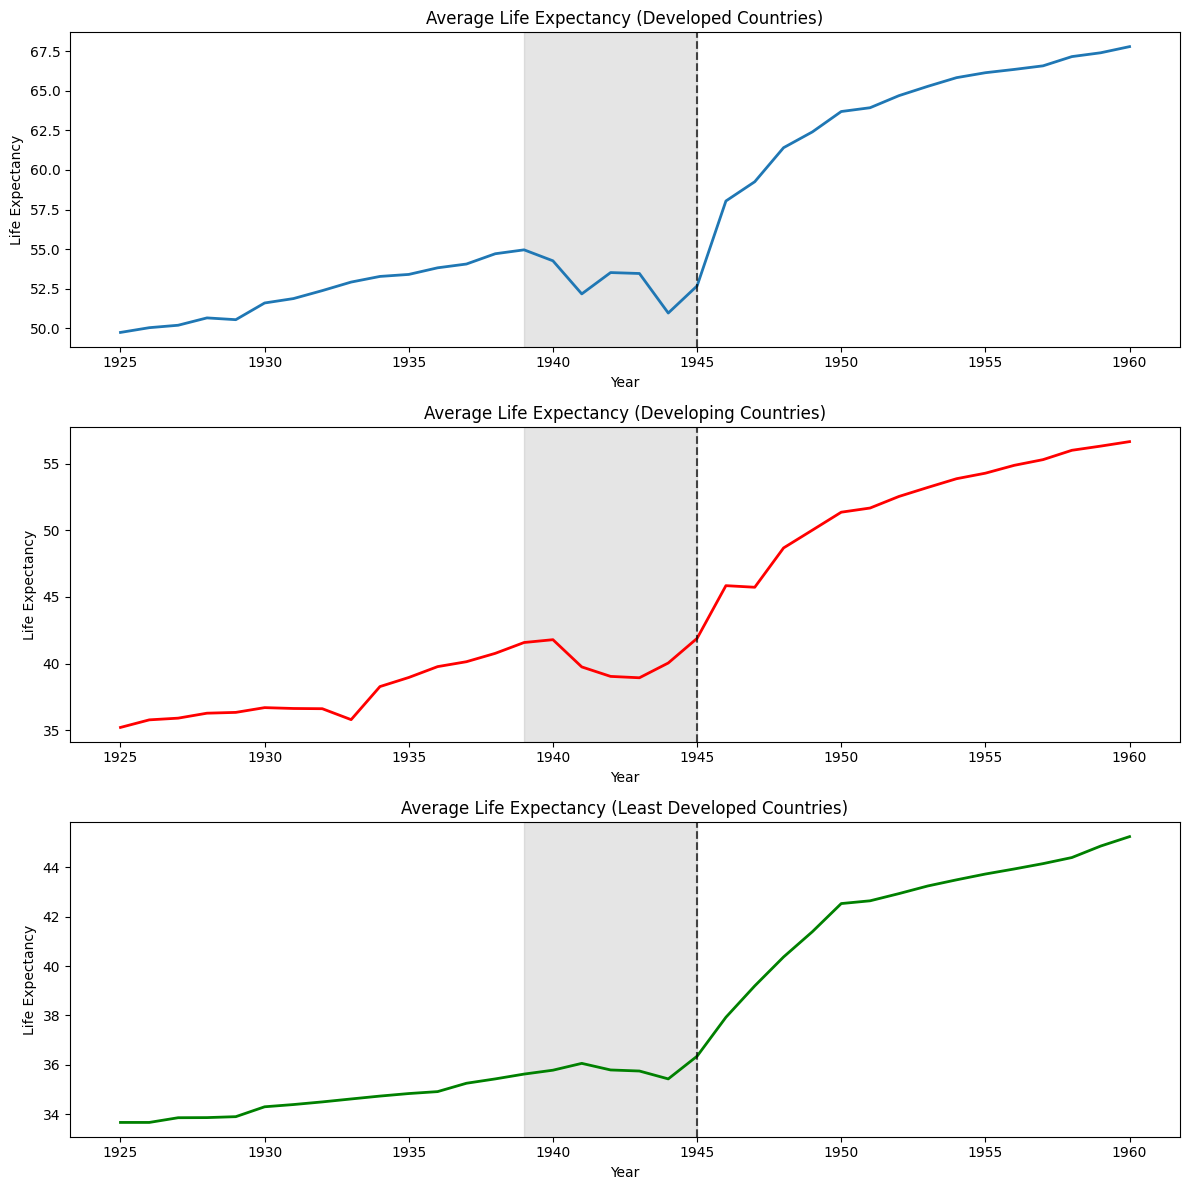

In [62]:
grouped_LE = df.groupby(['Year', 'Country_class'])['LE'].mean().unstack()

plt.figure(figsize=(12,12))

# -----------------------------
# Developed countries
# -----------------------------
plt.subplot(3,1,1)

plt.plot(
    grouped_LE.index,
    grouped_LE['Developed'],
    linewidth=2
)

# WWII period
plt.axvspan(1939, 1945, color='gray', alpha=0.2)

# End of war marker
plt.axvline(
    x=1945,
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.title('Average Life Expectancy (Developed Countries)')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')



# -----------------------------
# Developing countries
# -----------------------------
plt.subplot(3,1,2)

plt.plot(
    grouped_LE.index,
    grouped_LE['Developing'],
    color='red',
    linewidth=2
)

plt.axvspan(1939, 1945, color='gray', alpha=0.2)

plt.axvline(
    x=1945,
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.title('Average Life Expectancy (Developing Countries)')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')



# -----------------------------
# Least developed countries
# -----------------------------
plt.subplot(3,1,3)

plt.plot(
    grouped_LE.index,
    grouped_LE['Least Developed'],
    color='green',
    linewidth=2
)

plt.axvspan(1939, 1945, color='gray', alpha=0.2)

plt.axvline(
    x=1945,
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.title('Average Life Expectancy (Least Developed Countries)')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')



plt.tight_layout()

plt.show()

<h1>CO2 Emissions</h1>

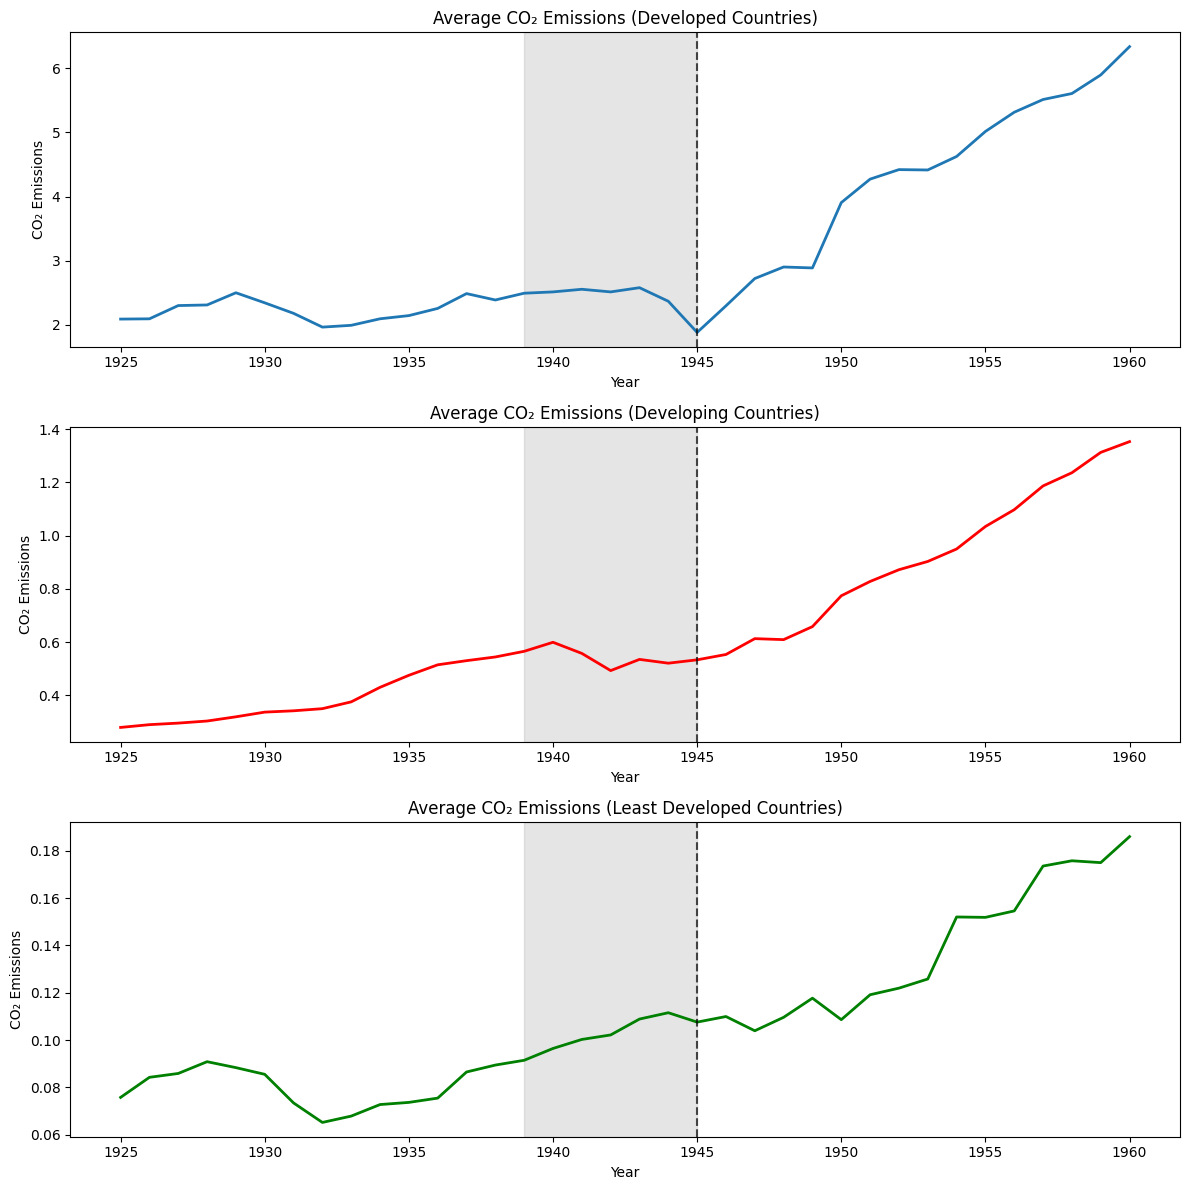

In [63]:
df_co2 = world_development_statistis_with_co2emission[
    (world_development_statistis_with_co2emission['Year'] >= 1925) &
    (world_development_statistis_with_co2emission['Year'] <= 1960)
]

grouped_co2 = df_co2.groupby(
    ['Year', 'Country_class']
)['co2_emissions'].mean().unstack()

plt.figure(figsize=(12,12))

# -----------------------------------
# Developed countries
# -----------------------------------
plt.subplot(3,1,1)

plt.plot(
    grouped_co2.index,
    grouped_co2['Developed'],
    linewidth=2
)

# WWII period
plt.axvspan(1939, 1945, color='gray', alpha=0.2)

# End of war marker
plt.axvline(
    x=1945,
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.title('Average CO₂ Emissions (Developed Countries)')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions')



# -----------------------------------
# Developing countries
# -----------------------------------
plt.subplot(3,1,2)

plt.plot(
    grouped_co2.index,
    grouped_co2['Developing'],
    color='red',
    linewidth=2
)

plt.axvspan(1939, 1945, color='gray', alpha=0.2)

plt.axvline(
    x=1945,
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.title('Average CO₂ Emissions (Developing Countries)')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions')



# -----------------------------------
# Least developed countries
# -----------------------------------
plt.subplot(3,1,3)

plt.plot(
    grouped_co2.index,
    grouped_co2['Least Developed'],
    color='green',
    linewidth=2
)

plt.axvspan(1939, 1945, color='gray', alpha=0.2)

plt.axvline(
    x=1945,
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.title('Average CO₂ Emissions (Least Developed Countries)')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions')



plt.tight_layout()

plt.show()

<h1>Gross National Income GNI (Japan)</h1>

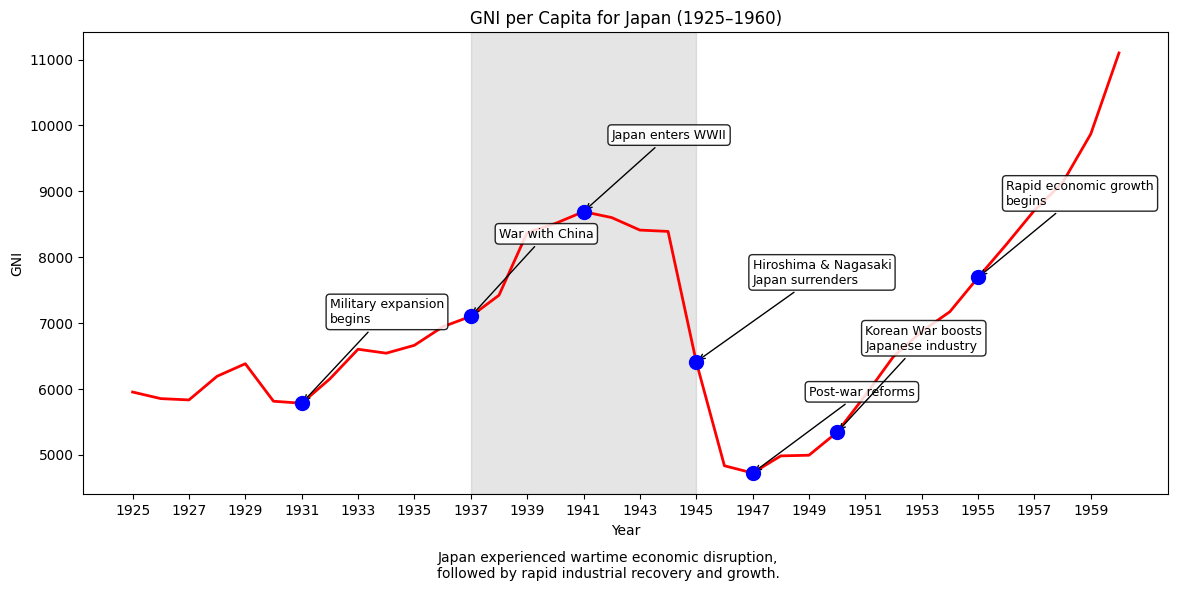

In [64]:
df = world_development_statistis[
    (world_development_statistis['country'] == 'Japan') &
    (world_development_statistis['Year'] >= 1925) &
    (world_development_statistis['Year'] <= 1960)
]

gni_by_year = df.groupby('Year')['GNI'].mean()

# Main plot
ax = gni_by_year.plot(
    figsize=(14,6),
    color='red',
    linewidth=2
)

# X-axis ticks
plt.xticks(range(1925, 1961, 2))

# WWII shaded period
plt.axvspan(1937, 1945, color='gray', alpha=0.2)

# Historical turning points
events = {
    1931: ('Military expansion\nbegins', (1932, 7000)),
    1937: ('War with China', (1938, 8300)),
    1941: ('Japan enters WWII', (1942, 9800)),
    1945: ('Hiroshima & Nagasaki\nJapan surrenders', (1947, 7600)),
    1947: ('Post-war reforms', (1949, 5900)),
    1950: ('Korean War boosts\nJapanese industry', (1951, 6600)),
    1955: ('Rapid economic growth\nbegins', (1956, 8800))
}

for year, (label, text_pos) in events.items():

    if year in gni_by_year.index:

        y = gni_by_year.loc[year]

        # Marker
        plt.scatter(
            year,
            y,
            color='blue',
            s=100,
            zorder=5
        )

        # Annotation
        plt.annotate(
            label,

            xy=(year, y),

            xytext=text_pos,

            arrowprops=dict(
                arrowstyle='->',
                color='black'
            ),

            bbox=dict(
                boxstyle='round,pad=0.3',
                fc='white',
                alpha=0.85
            ),

            fontsize=9
        )
# Titles
plt.title('GNI per Capita for Japan (1925–1960)')
plt.xlabel('Year')
plt.ylabel('GNI')

plt.figtext(
    0.5,
    -0.03,
    'Japan experienced wartime economic disruption,\n'
    'followed by rapid industrial recovery and growth.',
    ha='center'
)

plt.show()

<h1>Life Expectancy (Japan)</h1>

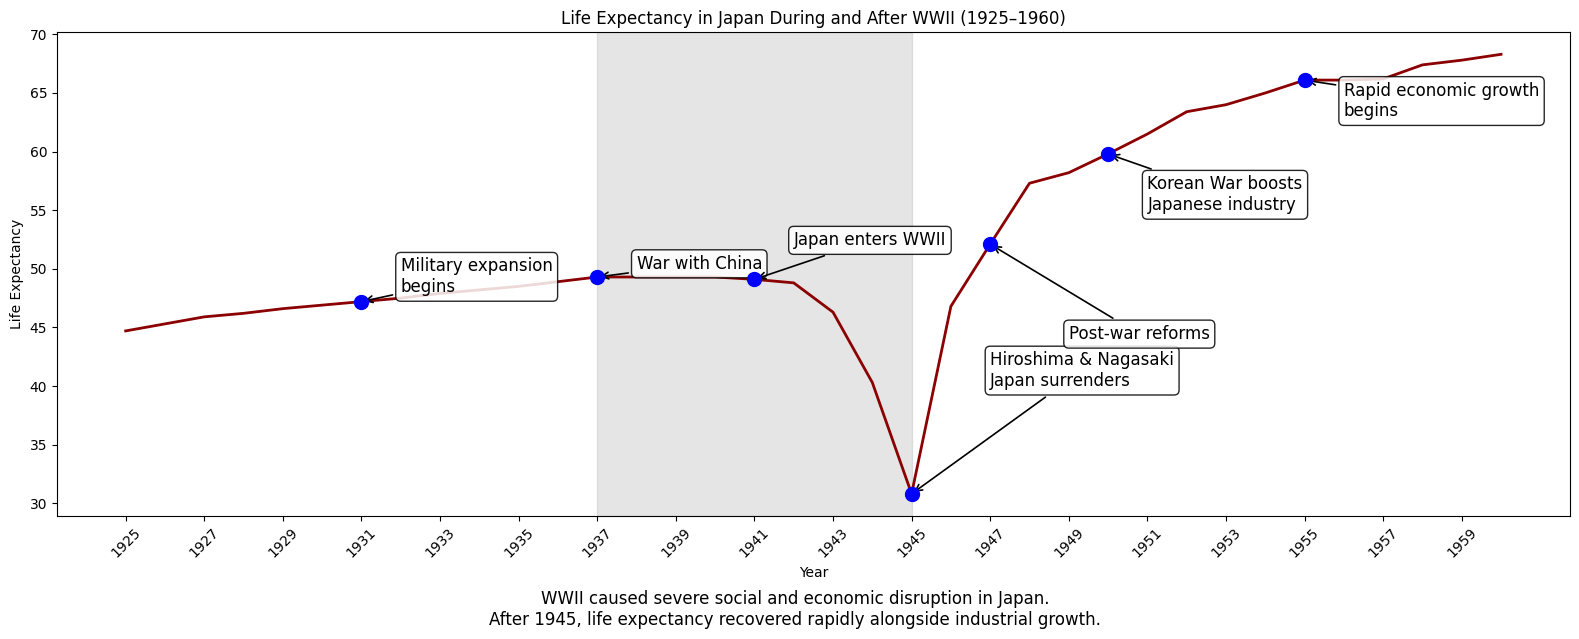

In [65]:


df = world_development_statistis[
    (world_development_statistis['country'] == 'Japan') &
    (world_development_statistis['Year'] >= 1925) &
    (world_development_statistis['Year'] <= 1960)
]

# Average life expectancy by year
le_by_year = df.groupby('Year')['LE'].mean()

# Main plot
ax = le_by_year.plot(
    figsize=(16,6),
    color='darkred',
    linewidth=2,
  
)

# X-axis ticks
plt.xticks(range(1925, 1961, 2), rotation=45)

# WWII shaded region
plt.axvspan(1937, 1945, color='gray', alpha=0.2)

# Historical events with realistic LE positions
events = {
    1931: ('Military expansion\nbegins', (1932, 48)),
    1937: ('War with China', (1938, 50)),
    1941: ('Japan enters WWII', (1942, 52)),
    1945: ('Hiroshima & Nagasaki\nJapan surrenders', (1947, 40)),
    1947: ('Post-war reforms', (1949, 44)),
    1950: ('Korean War boosts\nJapanese industry', (1951, 55)),
    1955: ('Rapid economic growth\nbegins', (1956, 63))
}

# Add markers + annotations
for year, (label, text_pos) in events.items():

    if year in le_by_year.index:

        y = le_by_year.loc[year]

        # Highlight event year
        plt.scatter(
            year,
            y,
            color='blue',
            s=100,
            zorder=5
        )

        # Annotation
        plt.annotate(
            label,

            xy=(year, y),

            xytext=text_pos,

            arrowprops=dict(
                arrowstyle='->',
                color='black',
                lw=1.2
            ),

            bbox=dict(
                boxstyle='round,pad=0.3',
                fc='white',
                alpha=0.85
            ),

            fontsize=12
        )

# Labels and title
plt.title('Life Expectancy in Japan During and After WWII (1925–1960)')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')

# Bottom explanation
plt.figtext(
    0.5,
    -0.05,
    'WWII caused severe social and economic disruption in Japan.\n'
    'After 1945, life expectancy recovered rapidly alongside industrial growth.',
    ha='center',
    fontsize=12
)



plt.tight_layout()

plt.show()

<h1>CO2 Emissions (Japan)</h1>

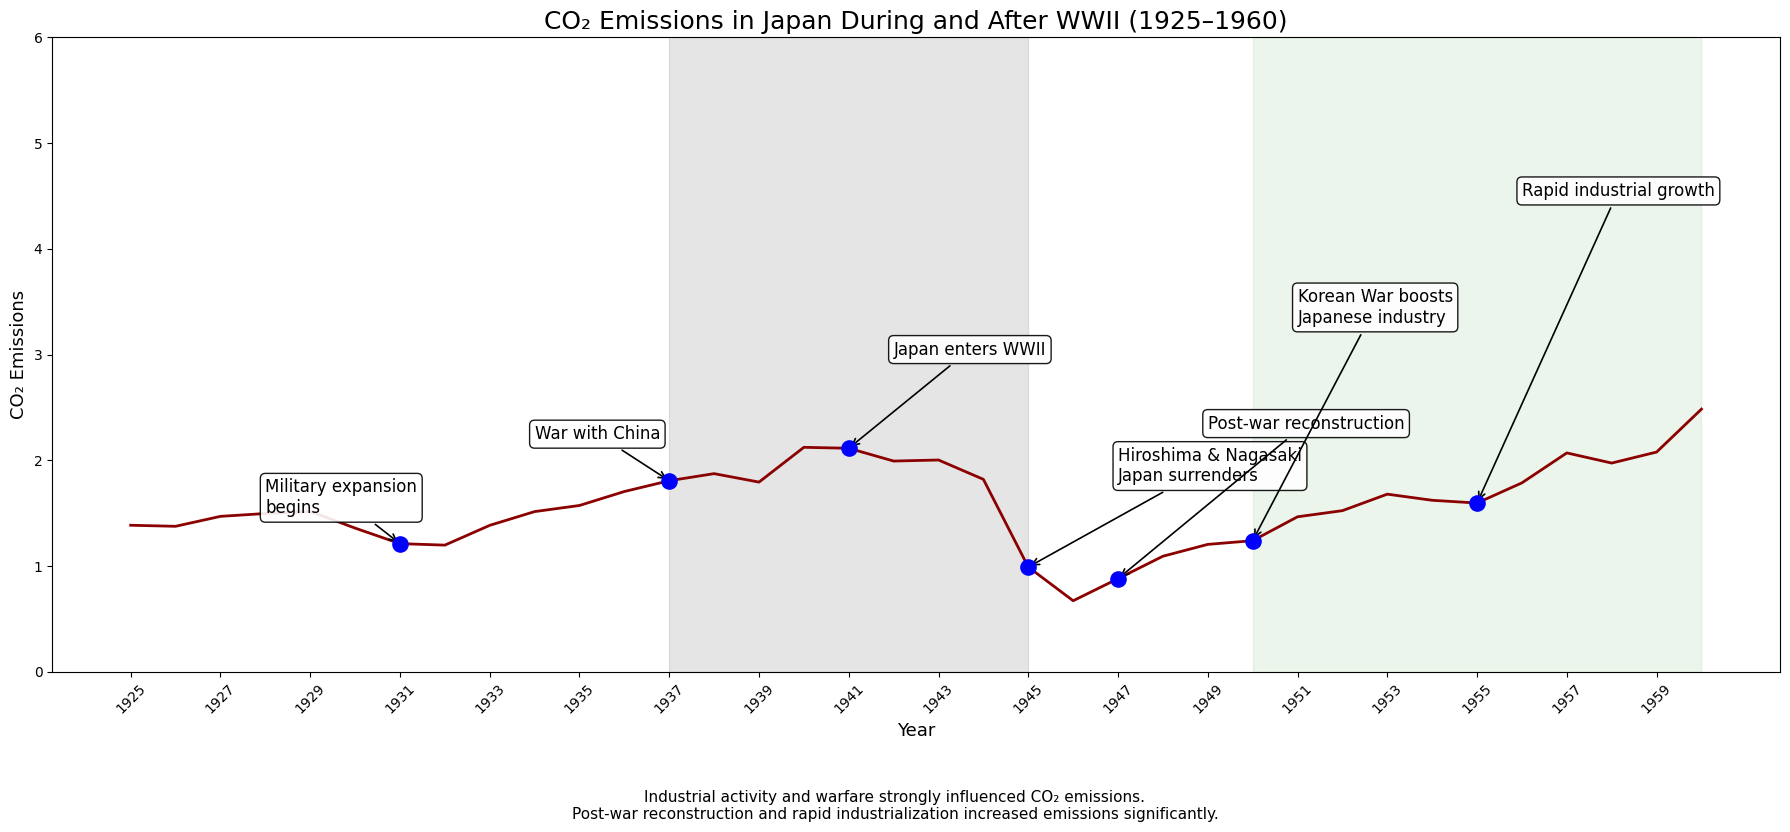

In [66]:
# Investigate the effect of WWII on CO2 emissions in Japan

df = world_development_statistis_with_co2emission[
    (world_development_statistis_with_co2emission['country'] == 'Japan') &
    (world_development_statistis_with_co2emission['Year'] >= 1925) &
    (world_development_statistis_with_co2emission['Year'] <= 1960)
]

# Average CO2 emissions by year
co2_emissions_by_year = (
    df.groupby('Year')['co2_emissions']
    .mean()
    .sort_index()
)

# Main plot
ax = co2_emissions_by_year.plot(
    figsize=(18,8),
    color='darkred',
    linewidth=2,
 
)

# X-axis ticks
plt.xticks(
    range(1925, 1961, 2),
    rotation=45
)

# Y-axis range
plt.ylim(0, 6)

# WWII shaded region
plt.axvspan(
    1937,
    1945,
    color='gray',
    alpha=0.2
)

# Post-war recovery region
plt.axvspan(
    1950,
    1960,
    color='green',
    alpha=0.08
)

# Historical events
events = {

    1931: (
        'Military expansion\nbegins',
        (1928, 1.5)
    ),

    1937: (
        'War with China',
        (1934, 2.2)
    ),

    1941: (
        'Japan enters WWII',
        (1942, 3.0)
    ),

    1945: (
        'Hiroshima & Nagasaki\nJapan surrenders',
        (1947, 1.8)
    ),

    1947: (
        'Post-war reconstruction',
        (1949, 2.3)
    ),

    1950: (
        'Korean War boosts\nJapanese industry',
        (1951, 3.3)
    ),

    1955: (
        'Rapid industrial growth',
        (1956, 4.5)
    )
}

# Add markers and annotations
for year, (label, text_pos) in events.items():

    if year in co2_emissions_by_year.index:

        y = co2_emissions_by_year.loc[year]

        # Marker
        plt.scatter(
            year,
            y,
            color='blue',
            s=120,
            zorder=5
        )

        # Annotation
        plt.annotate(
            label,

            xy=(year, y),

            xytext=text_pos,

            arrowprops=dict(
                arrowstyle='->',
                color='black',
                lw=1.2
            ),

            bbox=dict(
                boxstyle='round,pad=0.3',
                fc='white',
                alpha=0.9
            ),

            fontsize=12
        )



# Labels and title
plt.title(
    'CO₂ Emissions in Japan During and After WWII (1925–1960)',
    fontsize=18
)

plt.xlabel(
    'Year',
    fontsize=13
)

plt.ylabel(
    'CO₂ Emissions',
    fontsize=13
)

# Bottom explanation
plt.figtext(
    0.5,
    -0.03,

    'Industrial activity and warfare strongly influenced CO₂ emissions.\n'
    'Post-war reconstruction and rapid industrialization increased emissions significantly.',

    ha='center',
    fontsize=11
)

# Layout fix
plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

<h1>Gross National Income GNI (Germany)</h1>

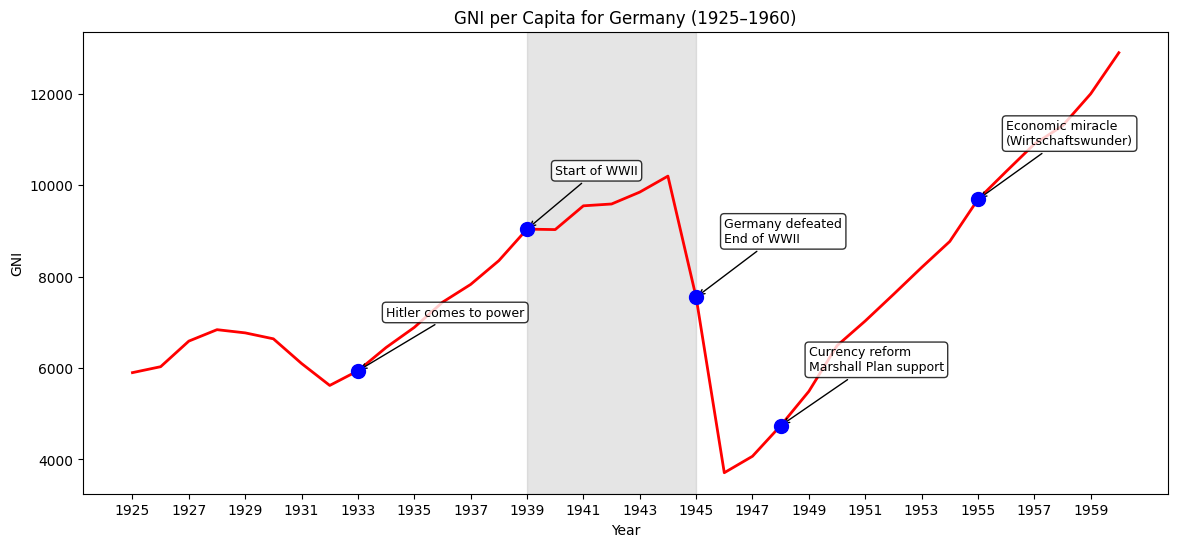

In [67]:
df = world_development_statistis[
    (world_development_statistis['country'] == 'Germany') &
    (world_development_statistis['Year'] >= 1925) &
    (world_development_statistis['Year'] <= 1960)
]

gni_by_year = df.groupby('Year')['GNI'].mean()

# Main line
ax = gni_by_year.plot(
    figsize=(14,6),
    color='red',
    linewidth=2
)

plt.xticks(range(1925, 1961, 2))

# WWII shaded area
plt.axvspan(1939, 1945, color='gray', alpha=0.2)

# Important historical years
events = {
    1933: 'Hitler comes to power',
    1939: 'Start of WWII',
    1945: 'Germany defeated\nEnd of WWII',
    1948: 'Currency reform\nMarshall Plan support',
    1955: 'Economic miracle\n(Wirtschaftswunder)'
}

# Plot markers + annotations only for event years
for year, label in events.items():

    # Skip if year missing in dataset
    if year in gni_by_year.index:

        y = gni_by_year.loc[year]

        # Special marker
        plt.scatter(
            year,
            y,
            color='blue',
            s=100,
            zorder=5
        )

        # Annotation
        plt.annotate(
            label,

            xy=(year, y),

            xytext=(year + 1, y + 1200),

            arrowprops=dict(
                arrowstyle='->',
                color='black'
            ),

            bbox=dict(
                boxstyle='round,pad=0.3',
                fc='white',
                alpha=0.8
            ),

            fontsize=9
        )

plt.title('GNI per Capita for Germany (1925–1960)')
plt.xlabel('Year')
plt.ylabel('GNI')



plt.show()

<h1>Life Expectancy (Germany)</h1>

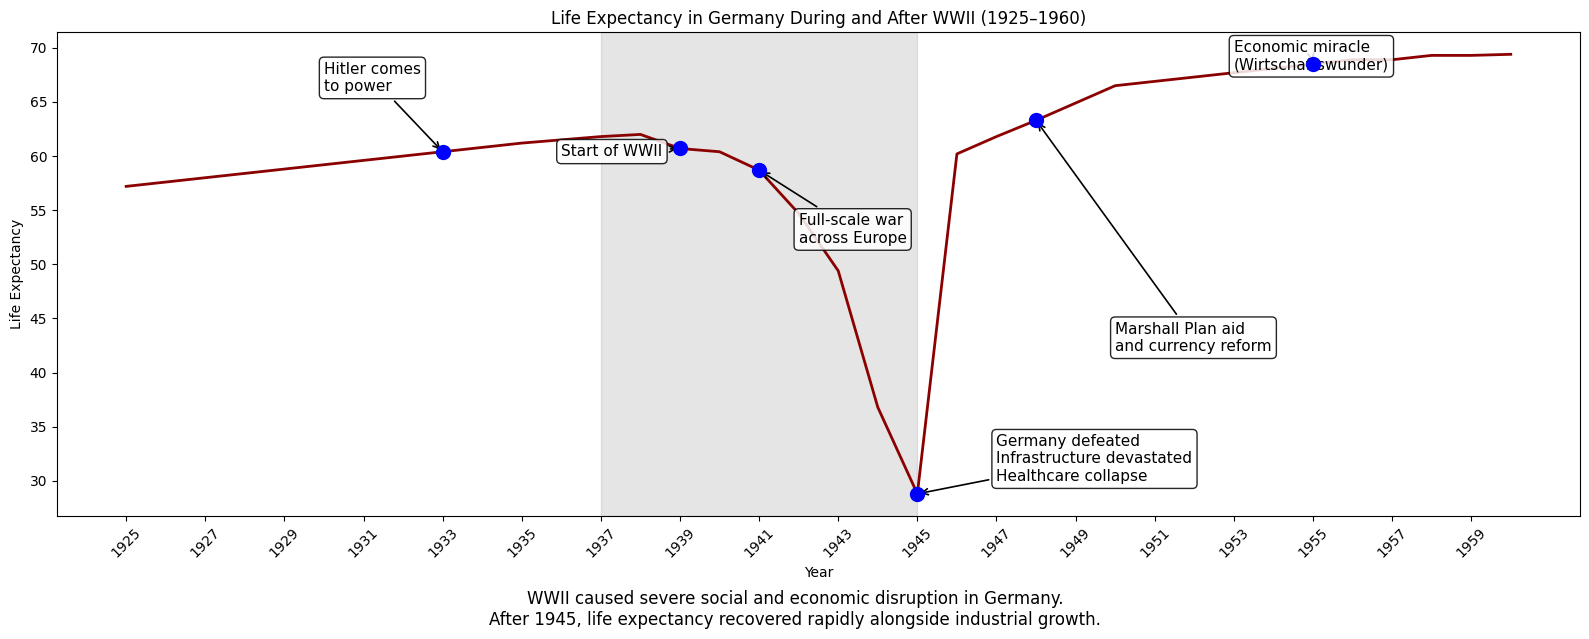

In [68]:
# Investigate the effect of WWII on life expectancy in Germany

df = world_development_statistis[
    (world_development_statistis['country'] == 'Germany') &
    (world_development_statistis['Year'] >= 1925) &
    (world_development_statistis['Year'] <= 1960)
]

# Average life expectancy by year
le_by_year = df.groupby('Year')['LE'].mean()

# Main plot
ax = le_by_year.plot(
    figsize=(16,6),
    color='darkred',
    linewidth=2,
  
)

# X-axis ticks
plt.xticks(range(1925, 1961, 2), rotation=45)

# WWII shaded region
plt.axvspan(1937, 1945, color='gray', alpha=0.2)

# Historical events with realistic LE positions
events = {
    1933: ('Hitler comes\nto power', (1930, 66)),

    1939: ('Start of WWII', (1936, 60)),

    1941: ('Full-scale war\nacross Europe', (1942, 52)),

    1945: ('Germany defeated\nInfrastructure devastated\nHealthcare collapse', (1947, 30)),

    1948: ('Marshall Plan aid\nand currency reform', (1950, 42)),

    1955: ('Economic miracle\n(Wirtschaftswunder)', (1953, 68))
}

for year, (label, text_pos) in events.items():

    if year in le_by_year.index:

        y = le_by_year.loc[year]

        plt.scatter(
            year,
            y,
            color='blue',
            s=100,
            zorder=5
        )

        plt.annotate(
            label,

            xy=(year, y),

            xytext=text_pos,

            arrowprops=dict(
                arrowstyle='->',
                color='black',
                lw=1.2
            ),

            bbox=dict(
                boxstyle='round,pad=0.3',
                fc='white',
                alpha=0.85
            ),

            fontsize=11
        )

# Labels and title
plt.title('Life Expectancy in Germany During and After WWII (1925–1960)')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')

# Bottom explanation
plt.figtext(
    0.5,
    -0.05,
    'WWII caused severe social and economic disruption in Germany.\n'
    'After 1945, life expectancy recovered rapidly alongside industrial growth.',
    ha='center',
    fontsize=12
)


plt.tight_layout()

plt.show()

<h1>CO2 Emissions (Germany)</h1>

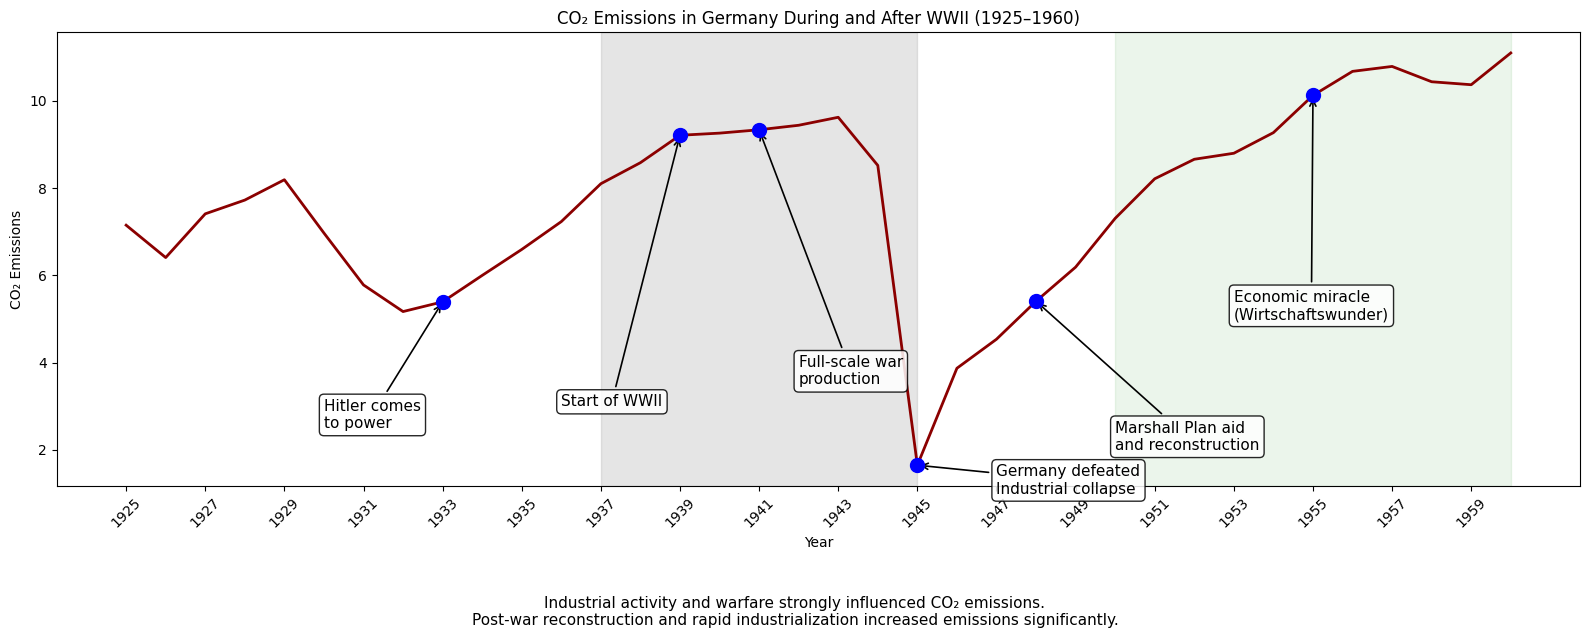

In [69]:
# Investigate the effect of WWII on CO2 emissions in Germany

df = world_development_statistis_with_co2emission[
    (world_development_statistis_with_co2emission['country'] == 'Germany') &
    (world_development_statistis_with_co2emission['Year'] >= 1925) &
    (world_development_statistis_with_co2emission['Year'] <= 1960)
]

# Average CO2 emissions by year
co2_emissions_by_year = df.groupby('Year')['co2_emissions'].mean()

# Main plot
ax = co2_emissions_by_year.plot(
    figsize=(16,6),
    color='darkred',
    linewidth=2,
   
)

# X-axis ticks
plt.xticks(range(1925, 1961, 2), rotation=45)

# WWII shaded region
plt.axvspan(1937, 1945, color='gray', alpha=0.2)

# Historical events

events = {
    1933: ('Hitler comes\nto power', (1930, 2.5)),

    1939: ('Start of WWII', (1936, 3.0)),

    1941: ('Full-scale war\nproduction', (1942, 3.5)),

    1945: ('Germany defeated\nIndustrial collapse', (1947, 1.0)),

    1948: ('Marshall Plan aid\nand reconstruction', (1950, 2.0)),

    1955: ('Economic miracle\n(Wirtschaftswunder)', (1953, 5.0))
}


for year, (label, text_pos) in events.items():

    if year in co2_emissions_by_year.index:

        y = co2_emissions_by_year.loc[year]

        plt.scatter(
            year,
            y,
            color='blue',
            s=100,
            zorder=5
        )

        plt.annotate(
            label,

            xy=(year, y),

            xytext=text_pos,

            arrowprops=dict(
                arrowstyle='->',
                color='black',
                lw=1.2
            ),

            bbox=dict(
                boxstyle='round,pad=0.3',
                fc='white',
                alpha=0.85
            ),

            fontsize=11
        )

# Labels and title
plt.title('CO₂ Emissions in Germany During and After WWII (1925–1960)')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions')
plt.axvspan(
    1950,
    1960,
    color='green',
    alpha=0.08
)
# Bottom explanation
plt.figtext(
    0.5,
    -0.05,
    'Industrial activity and warfare strongly influenced CO₂ emissions.\n'
    'Post-war reconstruction and rapid industrialization increased emissions significantly.',
    ha='center',
    fontsize=11
)



# Layout fix
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()